In [84]:
# Dataset fetching libraries
import kagglehub

# Data processing libraries
import os
import glob
from pathlib import Path
from PIL import Image
import numpy as np
from skimage.filters import gabor
from scipy.ndimage import convolve
from scipy import ndimage as ndi
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

# Classical ML Algorithms
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score,accuracy_score,precision_score,recall_score,f1_score
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# Deep Learning Models
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# ML Explainability
import shap
import cv2

# 0: Task 2: Image Data (PlantVillage Crop Disease Classification)

Objective: Build and Compare classical and deep learning CNN models to classify crop leaf images by plant species and disease type

Dataset Source: https://www.kaggle.com/datasets/emmarex/plantdisease/data

In [36]:
# Download latest version
path = kagglehub.dataset_download("emmarex/plantdisease",force_download=True)
print("Path to dataset files:", path)

100%|██████████| 658M/658M [01:05<00:00, 10.5MB/s] 

Extracting files...


Path to dataset files: /home/datascience/.cache/kagglehub/datasets/emmarex/plantdisease/versions/1


In [37]:
data_directory=str(Path.home())+'/.cache/kagglehub/datasets/emmarex/plantdisease/versions/1/PlantVillage'

# 1. Understanding the Data

# 1.1 Creating a Tensorflow Image Dataset

In [39]:
dataset = tf.keras.utils.image_dataset_from_directory(
        data_directory,
        labels='inferred',  # Infer labels from directory names
        label_mode='int',    # Labels will be integer-encoded
        image_size=(224, 224),
        interpolation='nearest',
        batch_size=32,
        shuffle=True  # Shuffle the data
)

Found 20638 files belonging to 15 classes.


## 1.2 Data Overview
- The Dataset has 206383 images belonging to 15 classes.
- The images are grouped into directories with each directory belonging to a specific class

### 1.2.1 Visualizing a sample images from the dataset

2025-12-09 02:40:31.901569: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


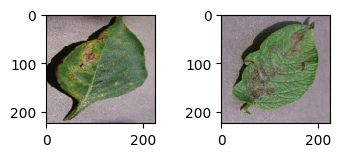

In [40]:
image_shape = ""
image_list=[]

for images, labels in dataset.take(1):
    for i in range(2):
        plt.subplot(330+1+i)
        plt.imshow(images[i],cmap='gray')
        image_shape=images[i].shape
        image_list.append(images[i].numpy())
plt.show()

### 1.2.2 Prepare the dataset for use with Artificial Neural Network Model

#### 1.2.2.1 Split the data into a training and testing set

In [41]:

train_ratio = 0.8
dataset_size = tf.data.experimental.cardinality(dataset).numpy() # Get dataset size

train_size = int(train_ratio * dataset_size)
test_size = dataset_size - train_size

# Shuffle the dataset (recommended for random splits)
# Use a seed for reproducibility
shuffled_dataset = dataset.shuffle(buffer_size=dataset_size, seed=42) 

# Split into train and test sets
train_dataset = shuffled_dataset.take(train_size)
test_dataset = shuffled_dataset.skip(train_size)


# 2. Preprocessing the Images

## 1.1 Resizing the images

In [42]:
def resize_image(img_path):
    try:
        img = Image.open(img_path)
        resized_img = img.resize((224,224)) 
        resized_img.save(img_path)
    except FileNotFoundError:
        print(f"Error: Image not found at {img_path}")
    except Exception as e:
        print(f"Error opening image: {e}")

In [43]:
path = Path(data_directory)

for lbl_path in path.iterdir():
    path_two= Path(lbl_path)
    for img_path in path_two.iterdir():
        resize_image(img_path)

Error opening image: cannot identify image file '/home/datascience/.cache/kagglehub/datasets/emmarex/plantdisease/versions/1/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/svn-r6Yb5c'


## 1.2 Normalize RGB Values

In [44]:
def normalize_rgb(img_path):
    try:
        img = Image.open(img_path).convert('RGB')
        img_np = np.array(img)
        normalized_img_np = img_np / 255.0
        normalized_img_pil = Image.fromarray((normalized_img_np * 255).astype(np.uint8))
        normalized_img_pil.save(img_path)
    except FileNotFoundError:
        print(f"Error: Image not found at {img_path}")
        
    except Exception as e:
        print(f"Error opening image: {e}")

In [45]:
path = Path(data_directory)

for lbl_path in path.iterdir():
    path_two= Path(lbl_path)
    for img_path in path_two.iterdir():
        normalize_rgb(img_path)

Error opening image: cannot identify image file '/home/datascience/.cache/kagglehub/datasets/emmarex/plantdisease/versions/1/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/svn-r6Yb5c'


# 2. Feature Extraction

## 2.1 Extracting Gabor Filters

In [46]:
def extract(img):
    frequencies = [0.1, 0.4]
    thetas = np.arange(0, np.pi, np.pi / 4) # 4 orientations
    filters = []
    
    for freq in frequencies:
        for theta in thetas:
            filt_real, filt_imag = gabor(img, frequency=freq, theta=theta)
            # Calculate magnitude response
            magnitude = np.sqrt(filt_real**2 + filt_imag**2)
            # Flatten the magnitude response to a 1D array
            filters.append(magnitude.flatten())
    return np.concatenate(filters)

## 2.2 Data Preparation

### 2.2.1 Creating a dataset with the Extracted Gabor Filters

In [47]:
classes=15

path = Path(data_directory)

features=[]
labels=[]

for lbl_path in path.iterdir():
    path_two= Path(lbl_path)
    count=0
    classes-=1
    
    for img_path in path_two.iterdir():
        count+=1
        img = Image.open(img_path)
        img_gray = img.convert('L') 
        img = np.array(img_gray)
        feature=extract(img)
        features.append(feature)
        labels.append(str(lbl_path).split('/')[-1])
        
        if(count==32):
            print('Collected Gabor Filters for a Batch Size of 32 from the class: %s'%str(path_two).split('/')[-1])
            print('Remaining classes: %s'%str(classes))
            print('........................................................................................')
            break

Collected Gabor Filters for a Batch Size of 32 from the class: Tomato_Early_blight
Remaining classes: 14
........................................................................................
Collected Gabor Filters for a Batch Size of 32 from the class: Tomato_healthy
Remaining classes: 13
........................................................................................
Collected Gabor Filters for a Batch Size of 32 from the class: Tomato_Leaf_Mold
Remaining classes: 12
........................................................................................
Collected Gabor Filters for a Batch Size of 32 from the class: Tomato_Spider_mites_Two_spotted_spider_mite
Remaining classes: 11
........................................................................................
Collected Gabor Filters for a Batch Size of 32 from the class: Tomato_Septoria_leaf_spot
Remaining classes: 10
........................................................................................
Collecte

In [48]:
X=np.array(features)
y = np.array(labels)

In [49]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

### 2.2.2 Splitting the data

In [50]:
X_train,X_test,y_train,y_test=train_test_split(X,y_encoded,train_size=0.7,random_state=0)

## 3. Model Creating and Evaluation

### 3.1 Classical ML Models

#### 3.1.1 Random Forest Classifier

##### 3.1.1.1 Training a Random Forest Classifier

In [51]:
RF_Model = RandomForestClassifier(n_estimators=100, random_state=42)

In [52]:
RF_Model.fit(X_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


##### 3.1.1.2 Evaluating a Random Forest Classifier

In [53]:
y_proba_RF=RF_Model.predict_proba(X_test)
y_pred_RF=RF_Model.predict(X_test)

In [54]:
RF_scores={
    'Model': 'Random Forest',
    'accuracy_score': accuracy_score(y_test,y_pred_RF),
    'precision_score': precision_score(y_test,y_pred_RF,average="macro"),
    'recall_score': recall_score(y_test,y_pred_RF,average="macro"),
    'f1_score': f1_score(y_test,y_pred_RF,average="macro")
}
RF_scores

{'Model': 'Random Forest',
 'accuracy_score': 0.2847222222222222,
 'precision_score': 0.31992845224303024,
 'recall_score': 0.317927442927443,
 'f1_score': 0.2640439514709051}

#### 3.1.2 Support Vector Machine Classifier

##### 3.1.2.1 Training a Support Vector Machine Forest Classifier

In [55]:
SVM_Model = svm.SVC(kernel='rbf', C=1, gamma='scale')

In [56]:
SVM_Model.fit(X_train,y_train)

,C,1
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


##### 3.1.2.2 Evaluating a Support Vector Machine Classifier

In [57]:
y_pred_SVM=SVM_Model.predict(X_test)

In [58]:
SVM_scores={
    'Model': 'Support Vector Machine',
    'accuracy_score': accuracy_score(y_test,y_pred_SVM),
    'precision_score': precision_score(y_test,y_pred_SVM,average="macro"),
    'recall_score': recall_score(y_test,y_pred_SVM,average="macro"),
    'f1_score': f1_score(y_test,y_pred_SVM,average="macro")
}
SVM_scores

/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'Model': 'Support Vector Machine',
 'accuracy_score': 0.2916666666666667,
 'precision_score': 0.3554259318585694,
 'recall_score': 0.341028416028416,
 'f1_score': 0.27119646943445574}

#### 3.1.3 K-NN

##### 3.1.3.1 Training a K-NN Classifier

In [59]:
knn_Model = KNeighborsClassifier(n_neighbors=3)

In [60]:
knn_Model.fit(X_train,y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


##### 3.1.3.2 Evaluating a Support Vector Machine Classifier

In [61]:
y_pred_knn=knn_Model.predict(X_test)

In [62]:
knn_scores={
    'Model': 'KNN Classifier',
    'accuracy_score': accuracy_score(y_test,y_pred_knn),
    'precision_score': precision_score(y_test,y_pred_knn,average="macro"),
    'recall_score': recall_score(y_test,y_pred_knn,average="macro"),
    'f1_score': f1_score(y_test,y_pred_knn,average="macro")
}
knn_scores

/opt/conda/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'Model': 'KNN Classifier',
 'accuracy_score': 0.1875,
 'precision_score': 0.2555780022446689,
 'recall_score': 0.20036260036260034,
 'f1_score': 0.15260046794408647}

### 3.2 Classical ML Model Performance Comparison

In [63]:
data=[RF_scores,SVM_scores,knn_scores]

In [64]:
score_comparison=pd.DataFrame(data)

In [65]:
score_comparison

,Model,accuracy_score,precision_score,recall_score,f1_score
0,Random Forest,0.284722,0.319928,0.317927,0.264044
1,Support Vector Machine,0.291667,0.355426,0.341028,0.271196
2,KNN Classifier,0.187500,0.255578,0.200363,0.152600


### 3.2 Deep Learning Models

#### 3.2.1 Using a Pretrained CNN - ResNet50

##### 3.2.1.1 Create a pretrained model and a customizable base model

In [86]:
model = ResNet50(weights='imagenet', include_top=True)

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

##### 3.2.1.2 Fine tune with additional layers on the base model

In [87]:
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x) 
predictions = tf.keras.layers.Dense(16, activation='softmax')(x) 

##### 3.2.1.3 Combine the pretrained and base models with an optimizer to track learning rate

In [89]:
model = tf.keras.models.Model(inputs=base_model.input, outputs=predictions)

optimizer = tf.keras.optimizers.Adam(
    learning_rate=tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.001,
        decay_steps=1000,
        decay_rate=0.95
    )
)

model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

##### 3.2.1.4 Train the Full Model

In [90]:
training_results=model.fit(train_dataset, epochs=1)

2025-12-09 06:31:43.543999: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:26: Filling up shuffle buffer (this may take a while): 379 of 645
2025-12-09 06:31:50.462087: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


516/516 ━━━━━━━━━━━━━━━━━━━━ 4942s 9s/step - accuracy: 0.8448 - loss: 0.5006


#### 3.2.2 Model Evaluation

##### 3.2.2.1 Accuracy

In [91]:
loss,accuracy = model.evaluate(test_dataset)

2025-12-09 07:59:34.984463: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:26: Filling up shuffle buffer (this may take a while): 376 of 645
2025-12-09 07:59:43.281570: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


129/129 ━━━━━━━━━━━━━━━━━━━━ 349s 3s/step - accuracy: 0.6584 - loss: 1.3805


In [92]:
CNN_scores={
    'Model': 'Fine Tuned ResNet50',
    'accuracy_score': accuracy
}
CNN_scores

{'Model': 'Fine Tuned ResNet50', 'accuracy_score': 0.6584302186965942}

##### 3.2.2.2 Comparison to Classical ML Models

In [93]:
data=[RF_scores,SVM_scores,knn_scores,CNN_scores]
score_comparison=pd.DataFrame(data)
score_comparison

,Model,accuracy_score,precision_score,recall_score,f1_score
0,Random Forest,0.284722,0.319928,0.317927,0.264044
1,Support Vector Machine,0.291667,0.355426,0.341028,0.271196
2,KNN Classifier,0.187500,0.255578,0.200363,0.152600
3,Fine Tuned ResNet50,0.658430,NaN,NaN,NaN


##### 3.2.2.3 Learning Rate

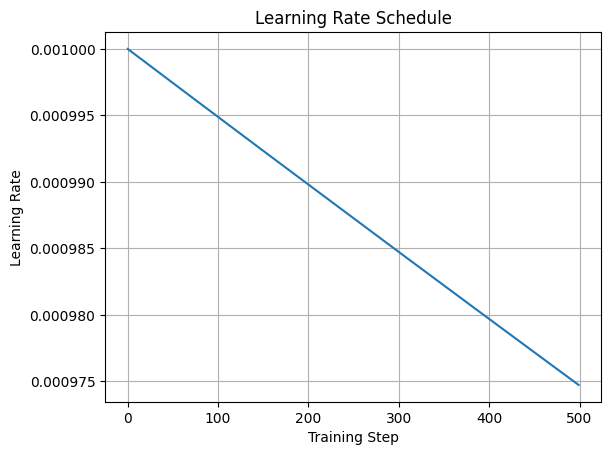

In [100]:
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=1000,
    decay_rate=0.95
)

steps = np.arange(0, 500) 
lrs = [lr_schedule(step).numpy() for step in steps]

plt.plot(steps, lrs)
plt.title("Learning Rate Schedule")
plt.xlabel("Training Step")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.show()

##### 3.2.2.4 Confusion Matrix

In [82]:
y_true=[]
y_pred=[]

for batch_x, batch_y in test_dataset:     
    preds = model.predict(batch_x)
    preds = np.argmax(preds, axis=1)       
    y_pred.extend(preds)
    y_true.extend(batch_y.numpy())

2025-12-09 06:13:52.500115: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:26: Filling up shuffle buffer (this may take a while): 388 of 645
2025-12-09 06:13:57.879194: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 

Text(0.5, 1.0, 'ResNet50 Confusion Matrix')

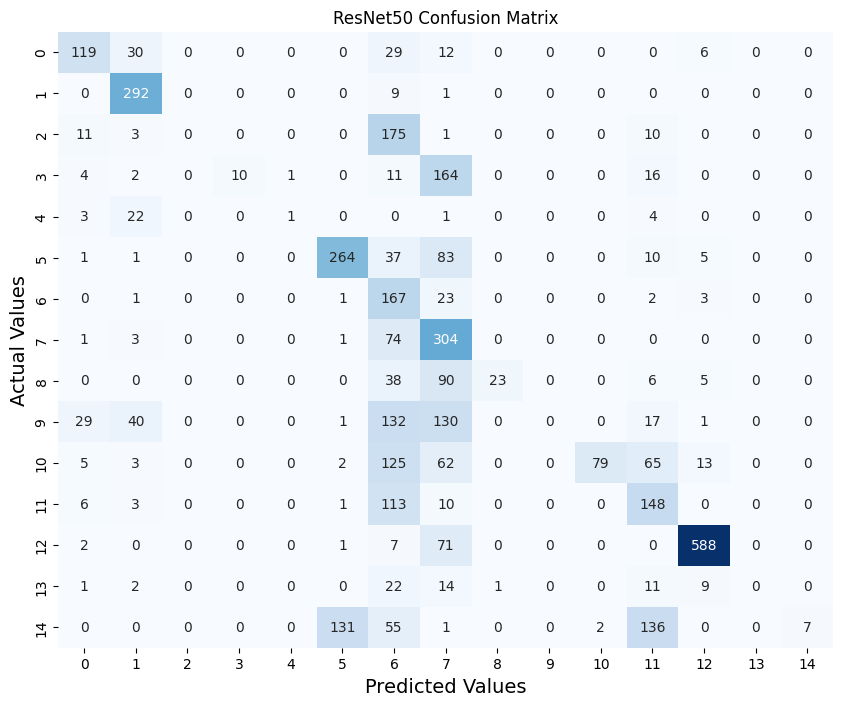

In [85]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Values', fontsize=14)
plt.ylabel('Actual Values', fontsize=14)
plt.title('ResNet50 Confusion Matrix')

#### 3.2.3 Model Explainability Using SHAP

  0%|          | 0/98 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:14, 14.38s/it]               


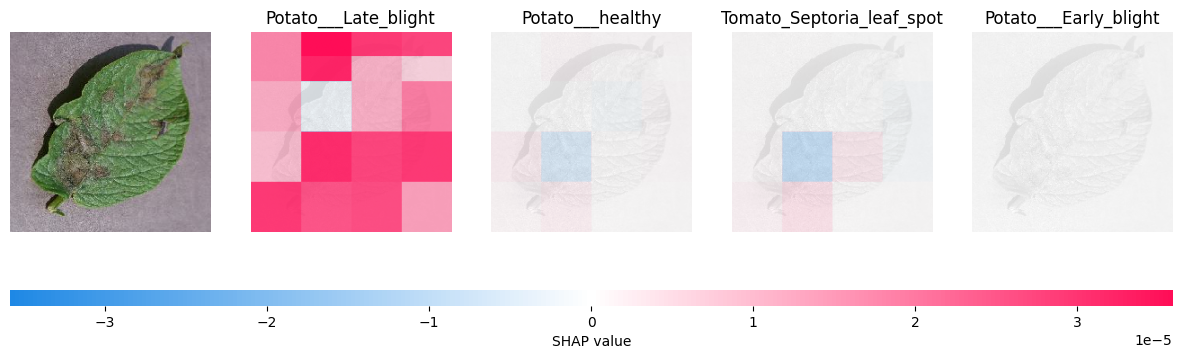

In [101]:
# define a masker that is used to mask out partitions of the input image.
masker = shap.maskers.Image("inpaint_telea", image_shape)

# create an explainer with model and image masker
explainer = shap.Explainer(model, masker, output_names=dataset.class_names)

# here we explain two images using 100 evaluations of the underlying model to estimate the SHAP values
shap_values = explainer(
   np.array(image_list)[1:3], max_evals=100, batch_size=50, outputs=shap.Explanation.argsort.flip[:4]
)
# output with shap values
shap.image_plot(shap_values)

## 4. Summary

This notebook applies classical and deep learning models to an image dataset. The iamge dataset contains crop leaf images categorized by plant species and disease type.

The following models have been used:

- Classical Supervised Models
    - SVM
    - Random Forest

- Classical Unsupervised Models

    -  K-Nearest Neighbors

- Deep Learning Models
      - Convoluted Neural Networks

The best performing classical model was the SVM Model which achieved an accuracy level of 25% which was far below the recommended accuracy benchmark

The Convoluted neural network achieved the highest accuracy level of 65% highlighting its suitability in terms of image processing.
- The Learning rate is stable during the early phases of training which is the ideal situation especially when training
models with noisy data such as images.
- The confusion matrix shows a strong prediction rate of correct classes for 10 out of the 15 classes in the dataset. This instills a very high confidence in the model to perform predictions on unseen data.
    - The SHAP explanation also support this as it is able to correctly predict the late blight class as highlighted with a lot      of red regions in the explanation visualization.
    